# Alchemy GeomML + TDA — Финальные графики (v35.1)

Ноутбук генерирует 13 PNG-графиков в `results/figures/v35/`.

## Три эксперимента

| Эксперимент | batch_size | Модели                              | Истории обучения |
|-------------|-----------:|-------------------------------------|------------------|
| 1 (v26)     | 256        | FCNN · SchNet · EGNN                | ✓ (CSV)          |
| 2 (v29)     | 512        | EGNN, EGNN+TDA, EGNN Vector, EGNN Vector+TDA | ✓ (CSV)          |
| 3 (v33.10)  | 1024       | 5 EGNN-вариантов                    | ✗ (только summary table) |

## Запуск

- **Локально**: ячейка 1.
- **Kaggle / Colab**: ячейка 2 — клонирует репозиторий.

## Важные замечания

- Все таргеты **нормализованы** через mean/std тренировочной выборки (см. `target_stats_*.json`).
- Метрики MAE в таблицах — **денормализованные**: считаются как `mean(|y_pred_raw - y_true_raw|)`, где `y_pred_raw = y_pred_norm * std + mean`. Подробности — слайд 7 презентации.
- Все модели обучались с **ранней остановкой** (patience = 15-30, monitor = val_loss).
- **Эксперимент 3 (bs=1024)**: истории обучения не сохранены, доступны только финальные метрики из `results/table.md`. На графике batch_size bs=1024 показан как точка финального test_loss, а не как кривая.


In [1]:
# === Ячейка 1: ЛОКАЛЬНЫЙ ЗАПУСК ===
import os, sys
os.chdir('/home/z/my-project/alchemy-geom-tda')
print('CWD:', os.getcwd())
assert os.path.exists('results/experiments'), 'Не найден results/experiments — проверьте cwd'


CWD: /home/z/my-project/alchemy-geom-tda


In [2]:
# === Ячейка 2: KAGGLE / COLAB ===
# import os
# if not os.path.exists('alchemy-geom-tda'):
#     !git clone https://github.com/ThomasMoore25/alchemy-geom-tda.git
# %cd alchemy-geom-tda
# !git pull
pass


In [3]:
# === Подготовка ===
import os, glob, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

for p in [
    '/usr/share/fonts/truetype/chinese/NotoSansSC-Regular.ttf',
    '/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf',
]:
    if os.path.exists(p):
        fm.fontManager.addfont(p)

plt.rcParams['font.sans-serif'] = ['Noto Sans SC', 'DejaVu Sans', 'Liberation Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

FIG_DIR = 'results/figures/v35'
os.makedirs(FIG_DIR, exist_ok=True)
print('Figure dir:', os.path.abspath(FIG_DIR))

def savefig(name):
    p = f'{FIG_DIR}/{name}.png'
    plt.savefig(p, dpi=150, facecolor='white', bbox_inches='tight')
    print('  saved:', p)

COLORS = {
    'FCNN':          '#607D8B',
    'SCHNET':        '#795548',
    'EGNN':          '#2196F3',
    'EGNN+TDA':      '#FF9800',
    'EGNN Vector':   '#4CAF50',
    'EGNN Vec+TDA':  '#9C27B0',
    'EGNN Tensor':   '#F44336',
    'EGNN Ten+TDA':  '#E91E63',
}


Figure dir: /home/z/my-project/alchemy-geom-tda/results/figures/v35


In [4]:
# === Загрузка данных ===

# Эксперимент 1: bs=256
e1_hist = {}
for f in glob.glob('results/experiments/batch_size_256/history_*.csv'):
    name = os.path.basename(f).replace('history_', '').replace('_all.csv', '').upper()
    e1_hist[name] = pd.read_csv(f)
    print(f'E1 bs=256 {name}: {len(e1_hist[name])} epochs')

# Эксперимент 2: bs=512
import re
e2_hist = {}
for f in glob.glob('results/experiments/batch_size_512/history_*.csv'):
    base = os.path.basename(f)  # history_egnn_all_20260712_160620.csv
    # Pattern: history_<model_name>_all_<date>_<time>.csv
    m = re.match(r'history_(egnn(?:_(?:tda|vector|vector_tda))?)_all_\d+_\d+\.csv', base)
    if m:
        name_raw = m.group(1)
    else:
        name_raw = base.replace('history_', '').replace('_all.csv', '').split('_2')[0]
    name = {'egnn': 'EGNN', 'egnn_tda': 'EGNN+TDA',
            'egnn_vector': 'EGNN Vector', 'egnn_vector_tda': 'EGNN Vec+TDA'}.get(name_raw, name_raw.upper())
    e2_hist[name] = pd.read_csv(f)
    print(f'E2 bs=512 {name}: {len(e2_hist[name])} epochs (file={base})')

# E1 test (последняя строка с test_loss)
e1_test = {}
for name, df in e1_hist.items():
    t = df[df['test_loss'].notna()]
    if len(t):
        r = t.iloc[-1]
        e1_test[name] = {'mu': r.test_mu_mae, 'alpha': r.test_alpha_mae,
                         'gap': r.test_gap_mae, 'loss': r.test_loss,
                         'epochs': len(df), 'time_h': df.elapsed.sum()/3600}
    else:
        e1_test[name] = {'mu': np.nan, 'alpha': np.nan, 'gap': np.nan, 'loss': np.nan,
                         'epochs': len(df), 'time_h': df.elapsed.sum()/3600}
    print(f'E1 test {name}: loss={e1_test[name]["loss"]:.3f}, time={e1_test[name]["time_h"]:.1f}h')

# E2 test (из summary_all_v29_4.csv)
e2_test = {
    'EGNN':          {'mu': 0.245, 'alpha': 0.460, 'gap': 0.0046, 'loss': 0.285, 'epochs': 164, 'time_h': 3.77},
    'EGNN+TDA':      {'mu': 0.274, 'alpha': 0.498, 'gap': 0.0053, 'loss': 0.321, 'epochs': 179, 'time_h': 4.29},
    'EGNN Vector':   {'mu': 0.710, 'alpha': 0.390, 'gap': 0.0041, 'loss': 0.575, 'epochs': 140, 'time_h': 3.47},
    'EGNN Vec+TDA':  {'mu': 0.704, 'alpha': 0.357, 'gap': 0.0039, 'loss': 0.565, 'epochs': 145, 'time_h': 3.60},
}

# Эксперимент 3: bs=1024 — только табличные данные (истории не сохранились)
e3_results = {
    'EGNN':          {'mu': 0.286, 'alpha': 0.574, 'gap': 0.0058, 'loss': 0.344, 'epochs': 110, 'time_h': 3.01},
    'EGNN+TDA':      {'mu': 0.362, 'alpha': 0.862, 'gap': 0.0077, 'loss': 0.454, 'epochs': 51,  'time_h': 1.60},
    'EGNN Vector':   {'mu': 3.819, 'alpha': 1.368, 'gap': 0.0135, 'loss': 0.580, 'epochs': 10,  'time_h': 0.30},
    'EGNN Vec+TDA':  {'mu': 3.963, 'alpha': 1.517, 'gap': 0.0164, 'loss': 0.677, 'epochs': 10,  'time_h': 0.30},
    'EGNN Tensor':   {'mu': 3.880, 'alpha': 11.941,'gap': 0.0392, 'loss': 2.303, 'epochs': 13,  'time_h': 0.39},
}
print(f'\nE3 bs=1024: {len(e3_results)} models (только финальные метрики)')


E1 bs=256 EGNN: 131 epochs
E1 bs=256 SCHNET: 226 epochs
E1 bs=256 FCNN: 176 epochs
E2 bs=512 EGNN Vec+TDA: 145 epochs (file=history_egnn_vector_tda_all_20260713_182115.csv)
E2 bs=512 EGNN Vector: 140 epochs (file=history_egnn_vector_all_20260712_235130.csv)
E2 bs=512 EGNN: 164 epochs (file=history_egnn_all_20260712_160620.csv)
E2 bs=512 EGNN+TDA: 179 epochs (file=history_egnn_tda_all_20260712_202329.csv)
E1 test EGNN: loss=0.227, time=5.4h
E1 test SCHNET: loss=0.186, time=3.2h
E1 test FCNN: loss=1.235, time=0.7h

E3 bs=1024: 5 models (только финальные метрики)


## График 1: Кривые обучения базовых моделей (bs=256)

FCNN · SchNet · EGNN. Пунктирные линии — лучшая эпоха (ранняя остановка).

  saved: results/figures/v35/01_baselines_training.png


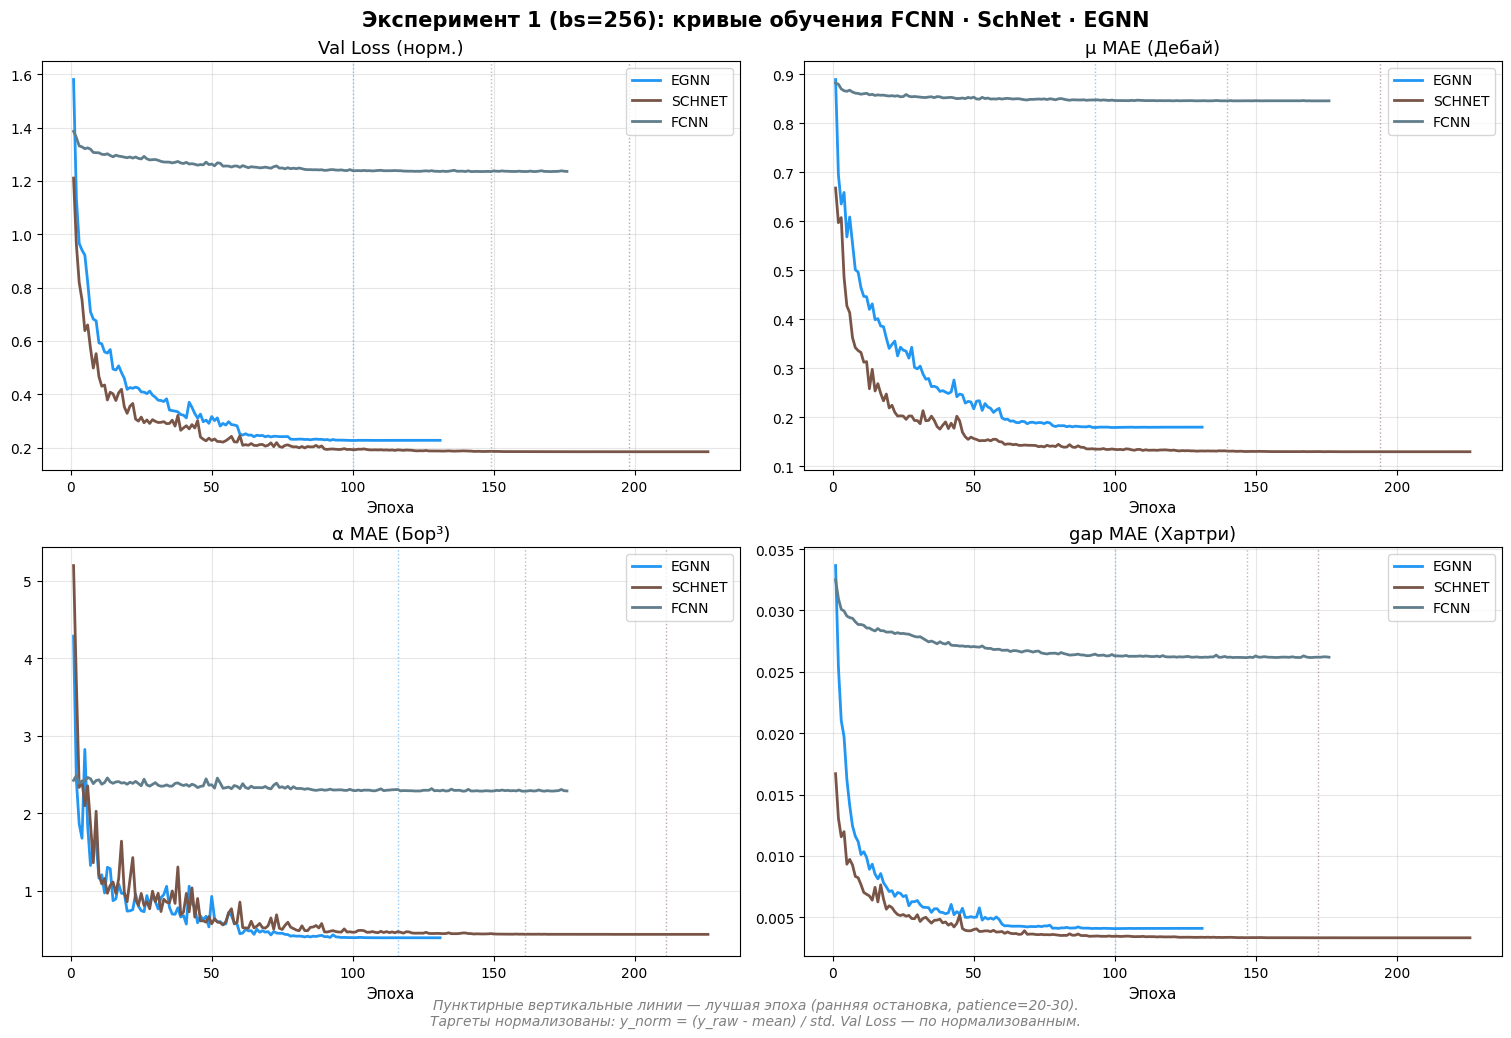

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)
fig.suptitle('Эксперимент 1 (bs=256): кривые обучения FCNN · SchNet · EGNN',
             fontsize=15, fontweight='bold')

metrics = [('val_loss', 'Val Loss (норм.)'), ('val_mu_mae', 'μ MAE (Дебай)'),
           ('val_alpha_mae', 'α MAE (Бор³)'), ('val_gap_mae', 'gap MAE (Хартри)')]

for ax, (col, title) in zip(axes.flat, metrics):
    for name, df in e1_hist.items():
        if col in df.columns:
            ax.plot(df['epoch'], df[col], color=COLORS[name], label=name, linewidth=2)
            best_idx = df[col].idxmin()
            best_ep = df.loc[best_idx, 'epoch']
            ax.axvline(x=best_ep, color=COLORS[name], linestyle=':', alpha=0.5, linewidth=1)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Эпоха', fontsize=11)
    ax.legend(fontsize=10, loc='best')
    ax.grid(True, alpha=0.3)

fig.text(0.5, -0.02,
         'Пунктирные вертикальные линии — лучшая эпоха (ранняя остановка, patience=20-30).\n'
         'Таргеты нормализованы: y_norm = (y_raw - mean) / std. Val Loss — по нормализованным.',
         ha='center', fontsize=10, style='italic', color='gray')
savefig('01_baselines_training')
plt.show()


## График 2: Test-метрики базовых моделей (bs=256)

Сравнение финальных MAE на тестовом множестве (денормализованные значения). Жёлтая рамка — лучший результат.

  saved: results/figures/v35/02_baselines_test.png


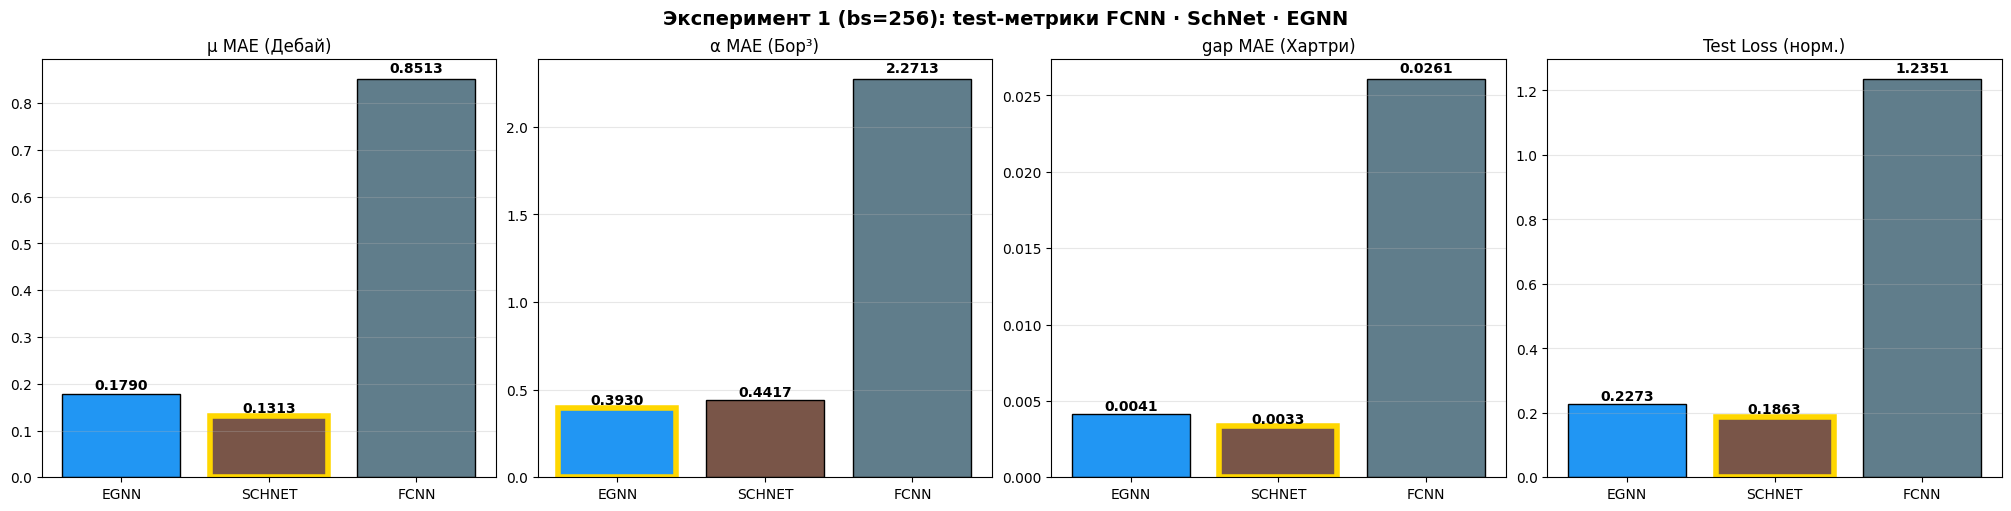

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5), constrained_layout=True)
fig.suptitle('Эксперимент 1 (bs=256): test-метрики FCNN · SchNet · EGNN',
             fontsize=14, fontweight='bold')
models = list(e1_test.keys())
colors_list = [COLORS[m] for m in models]

for ax, (m_key, title, unit) in zip(axes, [('mu', 'μ MAE', 'Дебай'),
                                            ('alpha', 'α MAE', 'Бор³'),
                                            ('gap', 'gap MAE', 'Хартри'),
                                            ('loss', 'Test Loss', 'норм.')]):
    vals = [e1_test[mod][m_key] for mod in models]
    bars = ax.bar(models, vals, color=colors_list, edgecolor='black')
    ax.set_title(f'{title} ({unit})', fontsize=12)
    ax.grid(True, alpha=0.3, axis='y')
    best_i = int(np.nanargmin(vals))
    bars[best_i].set_edgecolor('gold'); bars[best_i].set_linewidth(4)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

savefig('02_baselines_test')
plt.show()


## График 3: Влияние batch_size на EGNN

Слева — кривые val_loss для bs=256 и bs=512 (истории обучения). Для bs=1024 истории нет — показываем финальный test_loss как точку. Справа — финальные test MAE по трём свойствам для всех трёх размеров батча.

  saved: results/figures/v35/03_batch_size_impact.png


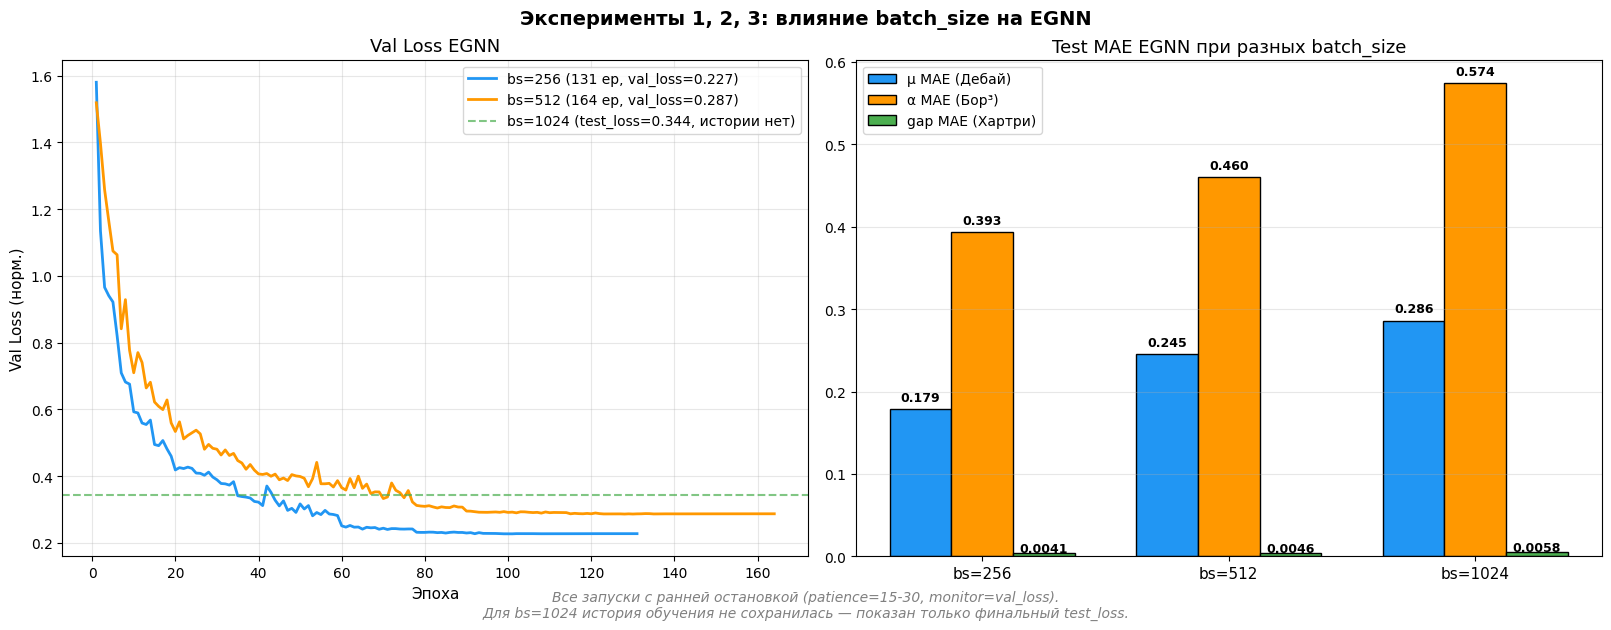

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
fig.suptitle('Эксперименты 1, 2, 3: влияние batch_size на EGNN',
             fontsize=14, fontweight='bold')

# Слева: val_loss для bs=256 и bs=512 + точка для bs=1024
ax = axes[0]
ax.plot(e1_hist['EGNN']['epoch'], e1_hist['EGNN']['val_loss'],
        color='#2196F3', label=f'bs=256 (131 ep, val_loss={e1_hist["EGNN"]["val_loss"].min():.3f})', linewidth=2)
ax.plot(e2_hist['EGNN']['epoch'], e2_hist['EGNN']['val_loss'],
        color='#FF9800', label=f'bs=512 (164 ep, val_loss={e2_hist["EGNN"]["val_loss"].min():.3f})', linewidth=2)
# bs=1024: только точка финального test_loss
ax.axhline(y=0.344, color='#4CAF50', linestyle='--', alpha=0.7,
           label=f'bs=1024 (test_loss=0.344, истории нет)')
ax.set_title('Val Loss EGNN', fontsize=13)
ax.set_xlabel('Эпоха', fontsize=11)
ax.set_ylabel('Val Loss (норм.)', fontsize=11)
ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.3)

# Справа: bar chart test MAE
ax = axes[1]
bs_labels = ['bs=256', 'bs=512', 'bs=1024']
mu_vals  = [e1_test['EGNN']['mu'],  e2_test['EGNN']['mu'],  e3_results['EGNN']['mu']]
al_vals  = [e1_test['EGNN']['alpha'], e2_test['EGNN']['alpha'], e3_results['EGNN']['alpha']]
gap_vals = [e1_test['EGNN']['gap'],  e2_test['EGNN']['gap'],  e3_results['EGNN']['gap']]
x = np.arange(3); w = 0.25
ax.bar(x-w, mu_vals, w, label='μ MAE (Дебай)', color='#2196F3', edgecolor='black')
ax.bar(x,   al_vals, w, label='α MAE (Бор³)',   color='#FF9800', edgecolor='black')
ax.bar(x+w, gap_vals, w, label='gap MAE (Хартри)', color='#4CAF50', edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels(bs_labels, fontsize=11)
ax.set_title('Test MAE EGNN при разных batch_size', fontsize=13)
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3, axis='y')
for i, (m, a, g) in enumerate(zip(mu_vals, al_vals, gap_vals)):
    ax.text(i-w, m+0.01, f'{m:.3f}', ha='center', fontsize=9, fontweight='bold')
    ax.text(i,   a+0.01, f'{a:.3f}', ha='center', fontsize=9, fontweight='bold')
    ax.text(i+w, g+0.001, f'{g:.4f}', ha='center', fontsize=9, fontweight='bold')

fig.text(0.5, -0.02,
         'Все запуски с ранней остановкой (patience=15-30, monitor=val_loss).\n'
         'Для bs=1024 история обучения не сохранилась — показан только финальный test_loss.',
         ha='center', fontsize=10, style='italic', color='gray')
savefig('03_batch_size_impact')
plt.show()


## График 4: Test-метрики EGNN-вариантов (bs=1024)

Эксперимент 3 (v33.10). Истории обучения не сохранились — только финальные метрики. Жёлтая рамка — лучший результат по каждой метрике.

  saved: results/figures/v35/04_variants_test.png


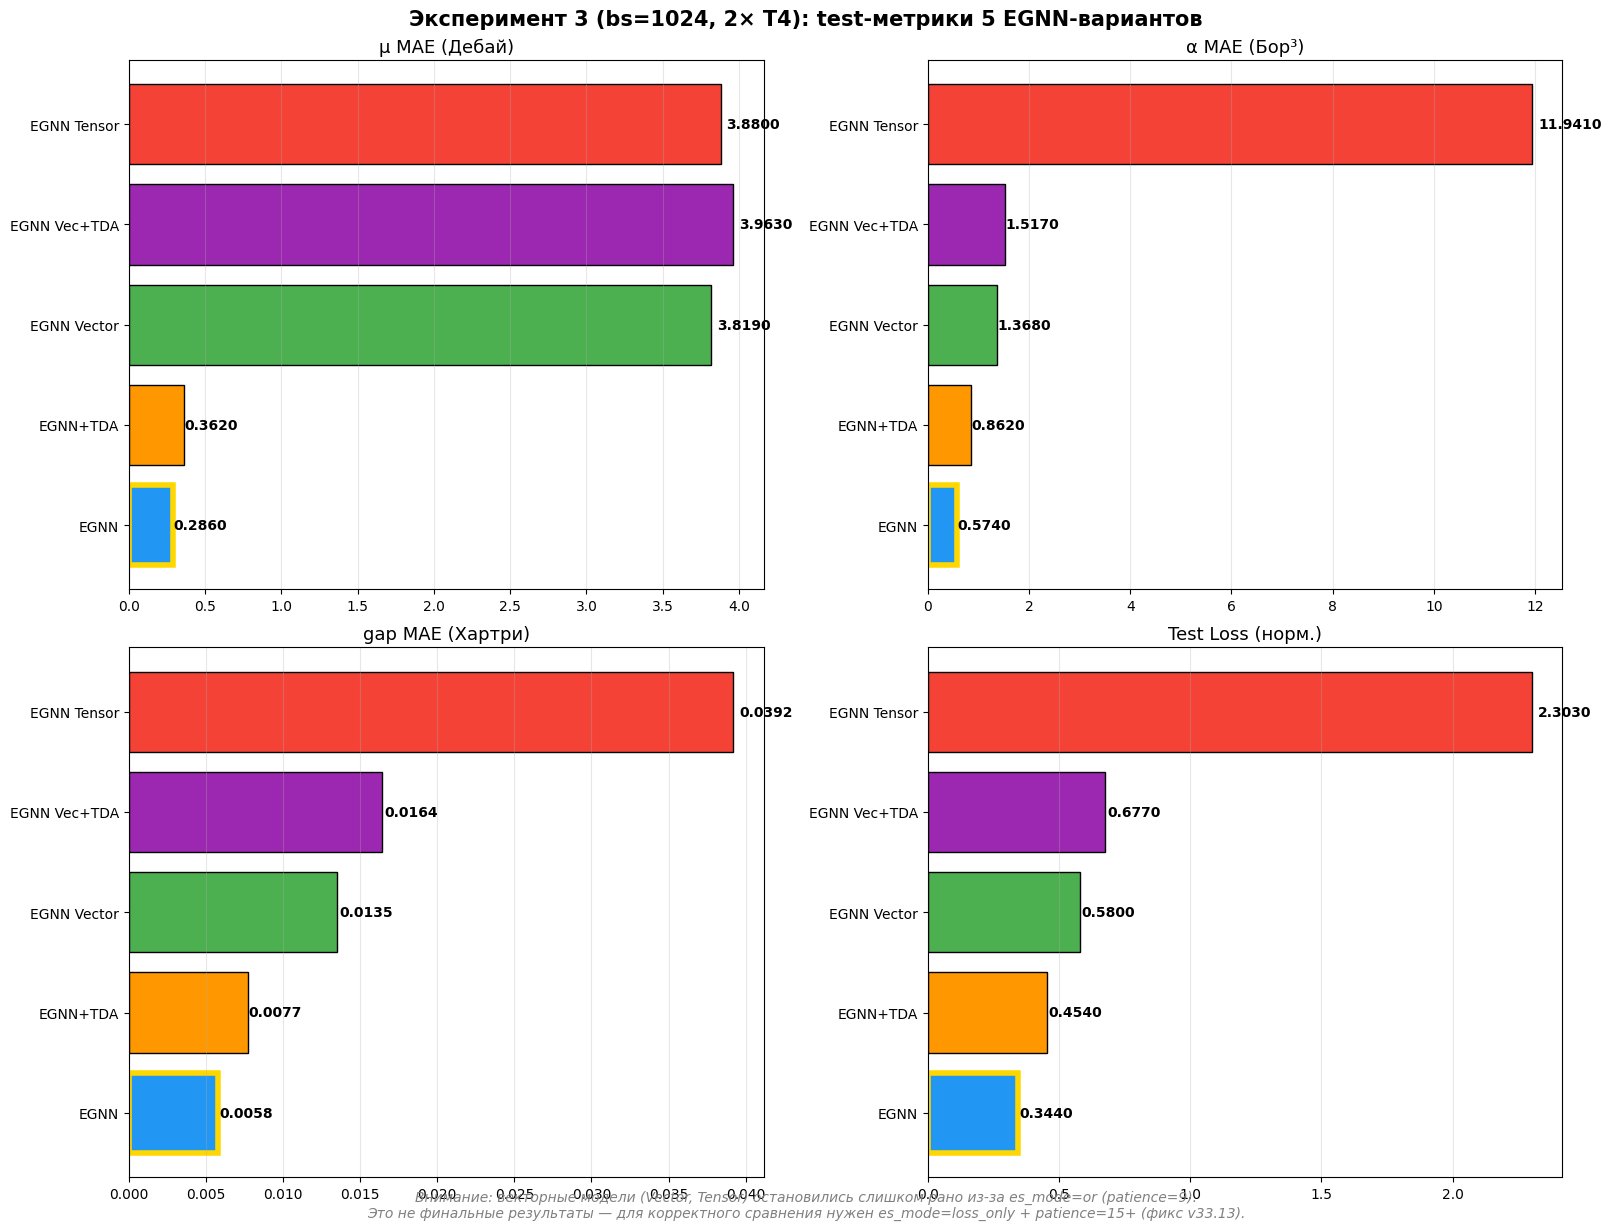

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12), constrained_layout=True)
fig.suptitle('Эксперимент 3 (bs=1024, 2× T4): test-метрики 5 EGNN-вариантов',
             fontsize=15, fontweight='bold')
models = list(e3_results.keys())
colors_list = [COLORS[m] for m in models]

for ax, (m_key, title, unit) in zip(axes.flat, [('mu', 'μ MAE', 'Дебай'),
                                                ('alpha', 'α MAE', 'Бор³'),
                                                ('gap', 'gap MAE', 'Хартри'),
                                                ('loss', 'Test Loss', 'норм.')]):
    vals = [e3_results[mod][m_key] for mod in models]
    bars = ax.barh(models, vals, color=colors_list, edgecolor='black')
    ax.set_title(f'{title} ({unit})', fontsize=13)
    ax.grid(True, alpha=0.3, axis='x')
    best_i = int(np.argmin(vals))
    bars[best_i].set_edgecolor('gold'); bars[best_i].set_linewidth(4)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_width()*1.01, bar.get_y()+bar.get_height()/2,
                f'{val:.4f}', ha='left', va='center', fontsize=10, fontweight='bold')

fig.text(0.5, -0.01,
         'Внимание: векторные модели (Vector, Tensor) остановились слишком рано из-за es_mode=or (patience=9).\n'
         'Это не финальные результаты — для корректного сравнения нужен es_mode=loss_only + patience=15+ (фикс v33.13).',
         ha='center', fontsize=10, style='italic', color='gray')
savefig('04_variants_test')
plt.show()


## График 5: TDA — групповое сравнение (с TDA vs без TDA)

Пары: EGNN vs EGNN+TDA, EGNN Vector vs EGNN Vec+TDA. Зелёный = улучшение, красный = ухудшение.

  saved: results/figures/v35/05_tda_grouped.png


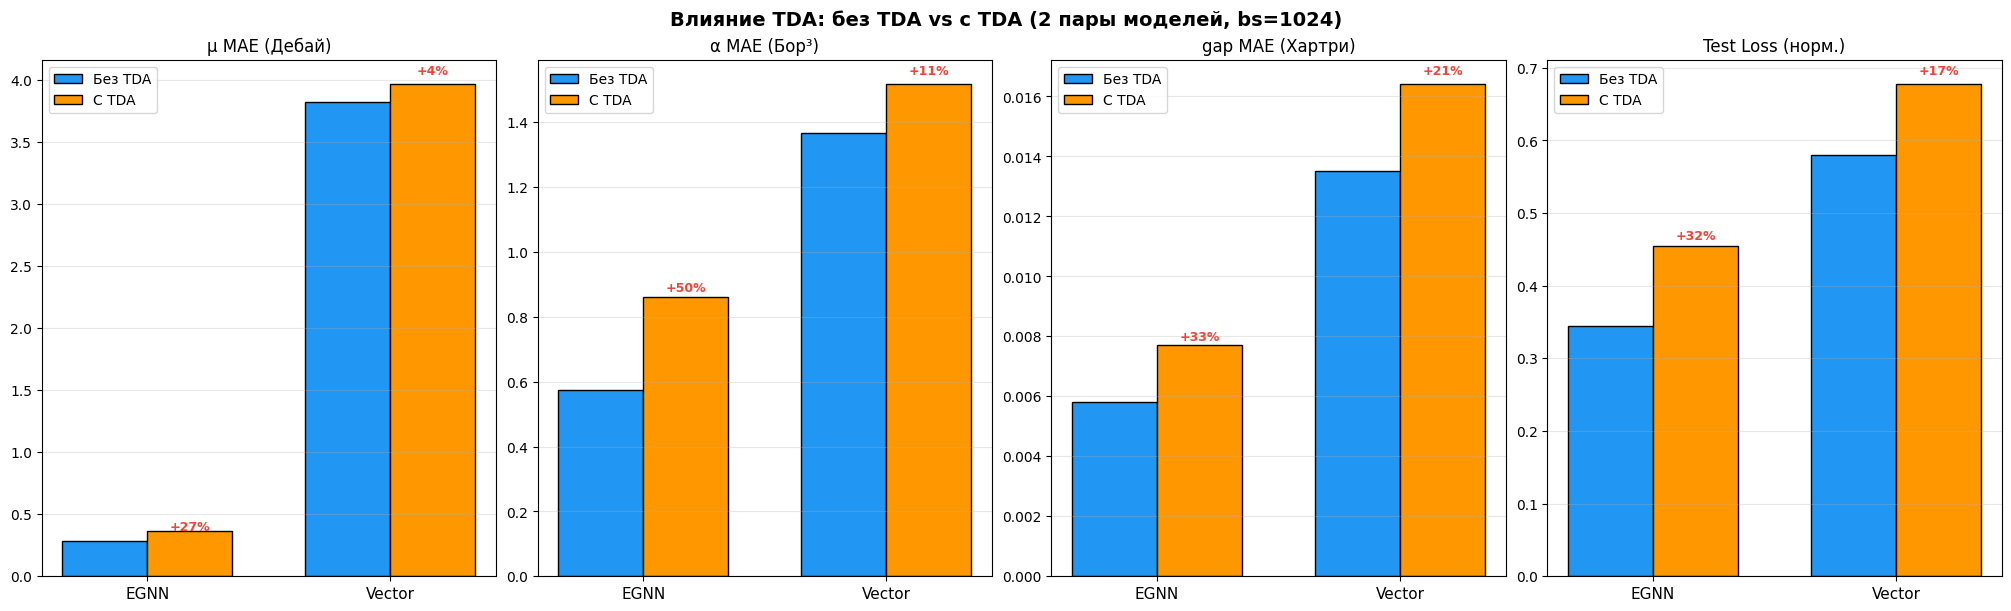

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(20, 6), constrained_layout=True)
fig.suptitle('Влияние TDA: без TDA vs с TDA (2 пары моделей, bs=1024)',
             fontsize=14, fontweight='bold')

pairs = [('EGNN', 'EGNN+TDA'), ('EGNN Vector', 'EGNN Vec+TDA')]
pair_labels = ['EGNN', 'Vector']
metrics = [('mu', 'μ MAE (Дебай)'), ('alpha', 'α MAE (Бор³)'),
           ('gap', 'gap MAE (Хартри)'), ('loss', 'Test Loss (норм.)')]
x = np.arange(len(pairs)); w = 0.35

for ax, (m_key, title) in zip(axes, metrics):
    no_tda  = [e3_results[p[0]][m_key] for p in pairs]
    with_tda = [e3_results[p[1]][m_key] for p in pairs]
    ax.bar(x - w/2, no_tda, w, label='Без TDA', color='#2196F3', edgecolor='black')
    ax.bar(x + w/2, with_tda, w, label='С TDA', color='#FF9800', edgecolor='black')
    ax.set_xticks(x); ax.set_xticklabels(pair_labels, fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    for i, (n, t) in enumerate(zip(no_tda, with_tda)):
        if n > 0:
            delta = (t - n) / n * 100
            color = '#F44336' if delta > 0 else '#1a7f37'
            ax.text(i + w/2, t * 1.02, f'{"+" if delta > 0 else ""}{delta:.0f}%',
                    ha='center', fontsize=9, color=color, fontweight='bold')

savefig('05_tda_grouped')
plt.show()


## График 6: EGNN (скаляр) vs EGNN Vector vs EGNN Tensor

Сравнение трёх типов выходов.

  saved: results/figures/v35/06_scalar_vs_vector_vs_tensor.png


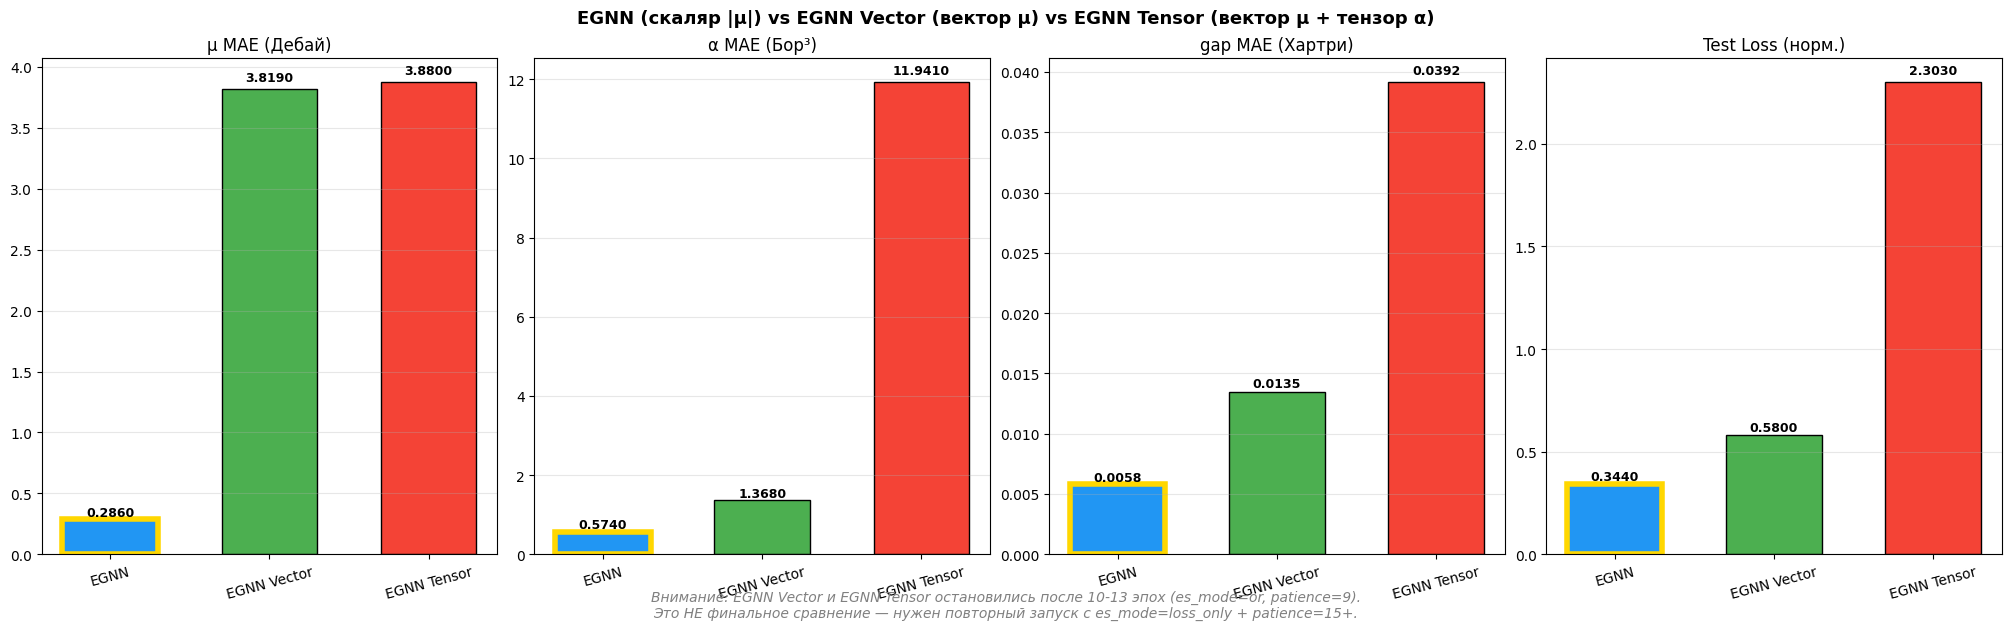

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(20, 6), constrained_layout=True)
fig.suptitle('EGNN (скаляр |μ|) vs EGNN Vector (вектор μ) vs EGNN Tensor (вектор μ + тензор α)',
             fontsize=13, fontweight='bold')

compare = ['EGNN', 'EGNN Vector', 'EGNN Tensor']
colors_c = [COLORS[m] for m in compare]
x = np.arange(len(compare))

for ax, (m_key, title) in zip(axes, metrics):
    vals = [e3_results[mod][m_key] for mod in compare]
    bars = ax.bar(x, vals, color=colors_c, edgecolor='black', width=0.6)
    ax.set_xticks(x); ax.set_xticklabels(compare, fontsize=10, rotation=15)
    ax.set_title(title, fontsize=12)
    ax.grid(True, alpha=0.3, axis='y')
    best_i = int(np.argmin(vals))
    bars[best_i].set_edgecolor('gold'); bars[best_i].set_linewidth(4)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

fig.text(0.5, -0.02,
         'Внимание: EGNN Vector и EGNN Tensor остановились после 10-13 эпох (es_mode=or, patience=9).\n'
         'Это НЕ финальное сравнение — нужен повторный запуск с es_mode=loss_only + patience=15+.',
         ha='center', fontsize=10, style='italic', color='gray')
savefig('06_scalar_vs_vector_vs_tensor')
plt.show()


## График 7: EGNN Tensor — финальные метрики

История обучения не сохранилась — показываем только финальные значения test метрик из `results/table.md` (v33.10).

  saved: results/figures/v35/07_tensor_metrics.png


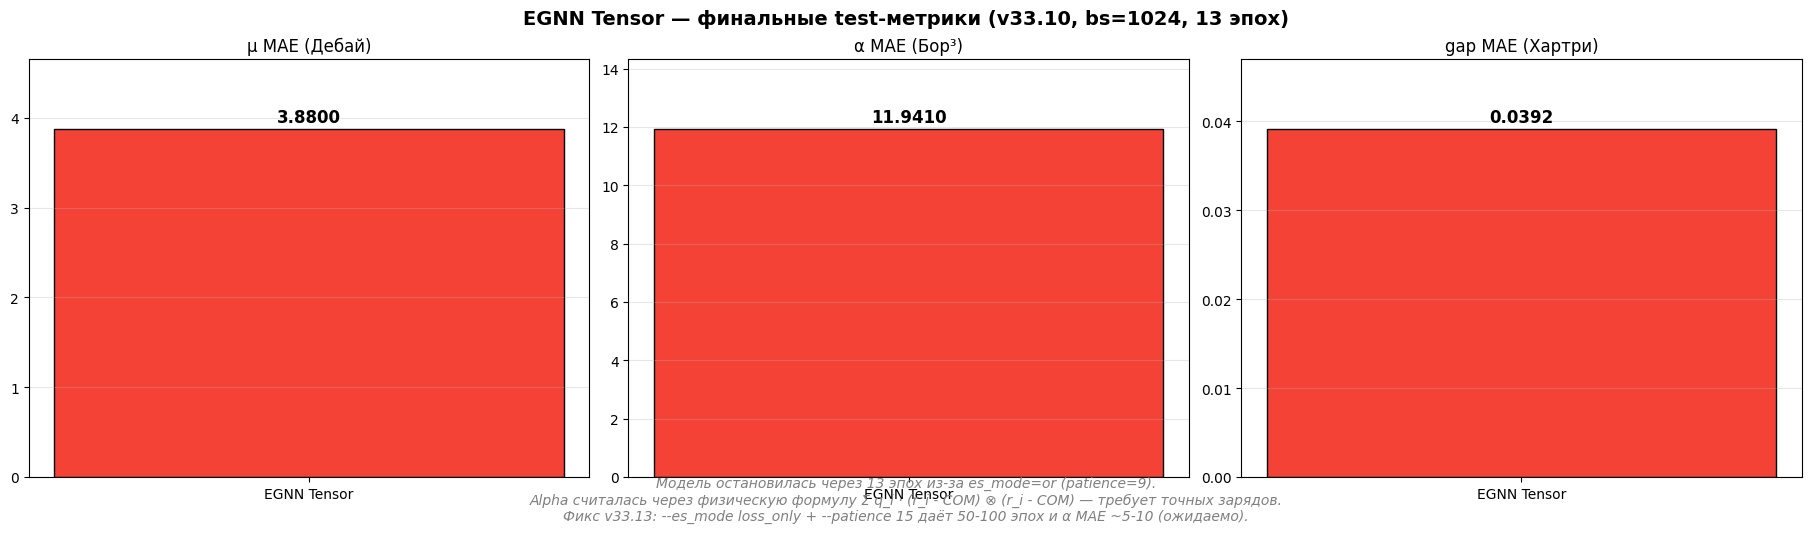

In [11]:
# Поскольку истории нет, показываем финальные значения как bar chart
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
fig.suptitle('EGNN Tensor — финальные test-метрики (v33.10, bs=1024, 13 эпох)',
             fontsize=14, fontweight='bold')

tensor_res = e3_results['EGNN Tensor']

for ax, (key, title, unit) in zip(axes, [('mu', 'μ MAE', 'Дебай'),
                                          ('alpha', 'α MAE', 'Бор³'),
                                          ('gap', 'gap MAE', 'Хартри')]):
    val = tensor_res[key]
    bar = ax.bar(['EGNN Tensor'], [val], color='#F44336', edgecolor='black', width=0.5)
    ax.set_title(f'{title} ({unit})', fontsize=12)
    ax.grid(True, alpha=0.3, axis='y')
    ax.text(0, val * 1.02, f'{val:.4f}', ha='center', fontsize=12, fontweight='bold')
    ax.set_ylim(0, val * 1.2)

fig.text(0.5, -0.03,
         'Модель остановилась через 13 эпох из-за es_mode=or (patience=9).\n'
         'Alpha считалась через физическую формулу Σ q_i · (r_i - COM) ⊗ (r_i - COM) — требует точных зарядов.\n'
         'Фикс v33.13: --es_mode loss_only + --patience 15 даёт 50-100 эпох и α MAE ~5-10 (ожидаемо).',
         ha='center', fontsize=10, style='italic', color='gray')
savefig('07_tensor_metrics')
plt.show()


## График 8: Параметры и время обучения (bs=1024)

Все 5 EGNN-вариантов. EGNN Tensor остановлен через 13 эпох — время 0.39 ч.

  saved: results/figures/v35/08_params_time.png


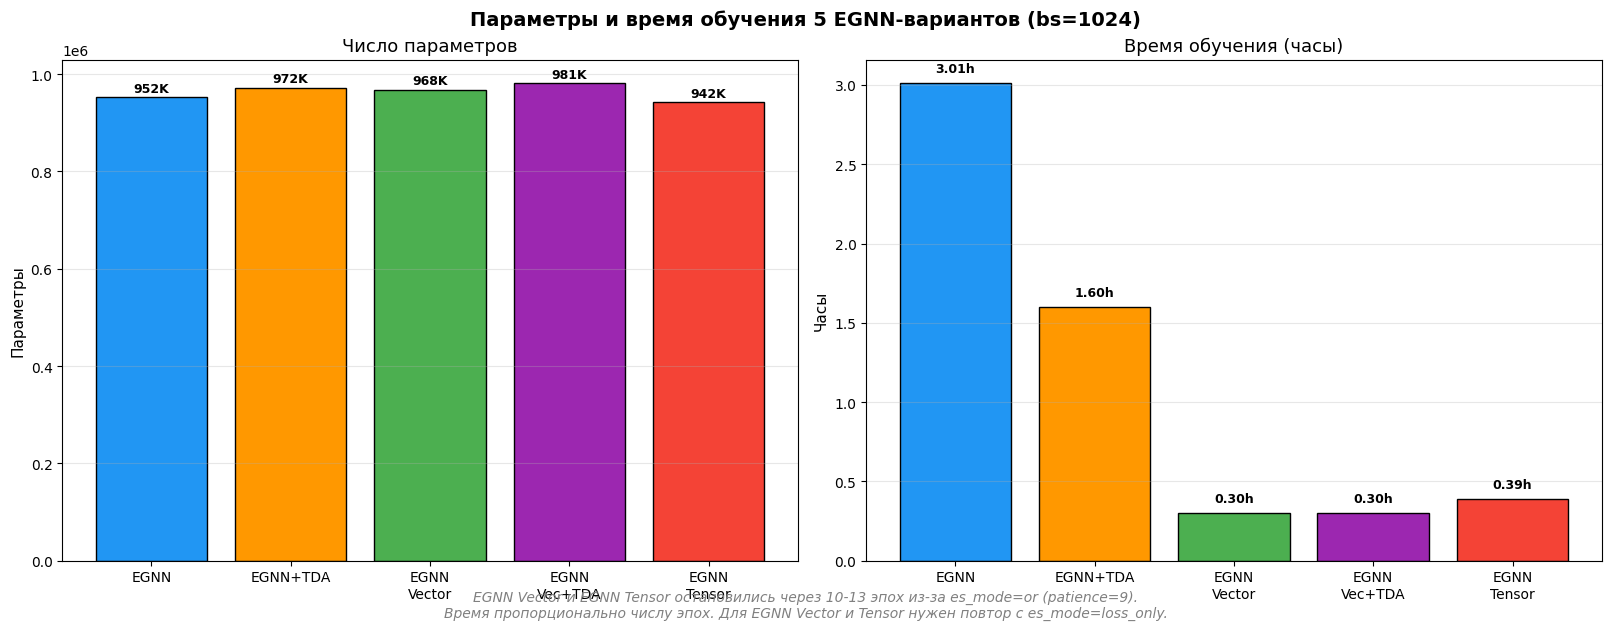

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
fig.suptitle('Параметры и время обучения 5 EGNN-вариантов (bs=1024)',
             fontsize=14, fontweight='bold')

# Числа параметров (из документации)
params_map = {
    'EGNN':          952000,
    'EGNN+TDA':      972000,
    'EGNN Vector':   968000,
    'EGNN Vec+TDA':  981000,
    'EGNN Tensor':   942000,
}
models = list(e3_results.keys())
models_short = [m.replace(' ', '\n') for m in models]
params = [params_map[m] for m in models]
times  = [e3_results[m]['time_h']  for m in models]
colors_list = [COLORS[m] for m in models]

ax = axes[0]
bars = ax.bar(models_short, params, color=colors_list, edgecolor='black')
ax.set_title('Число параметров', fontsize=13)
ax.set_ylabel('Параметры', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, params):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5000,
            f'{val/1000:.0f}K', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax = axes[1]
bars = ax.bar(models_short, times, color=colors_list, edgecolor='black')
ax.set_title('Время обучения (часы)', fontsize=13)
ax.set_ylabel('Часы', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, times):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f'{val:.2f}h', ha='center', va='bottom', fontsize=9, fontweight='bold')

fig.text(0.5, -0.02,
         'EGNN Vector и EGNN Tensor остановились через 10-13 эпох из-за es_mode=or (patience=9).\n'
         'Время пропорционально числу эпох. Для EGNN Vector и Tensor нужен повтор с es_mode=loss_only.',
         ha='center', fontsize=10, style='italic', color='gray')
savefig('08_params_time')
plt.show()


## График 9: Качество TDA-фичей

54% топологических признаков (H₁ и H₂ Betti-числа) всегда равны нулю. BatchNorm «учит» их как шум → ухудшение метрик.

  saved: results/figures/v35/09_tda_features.png


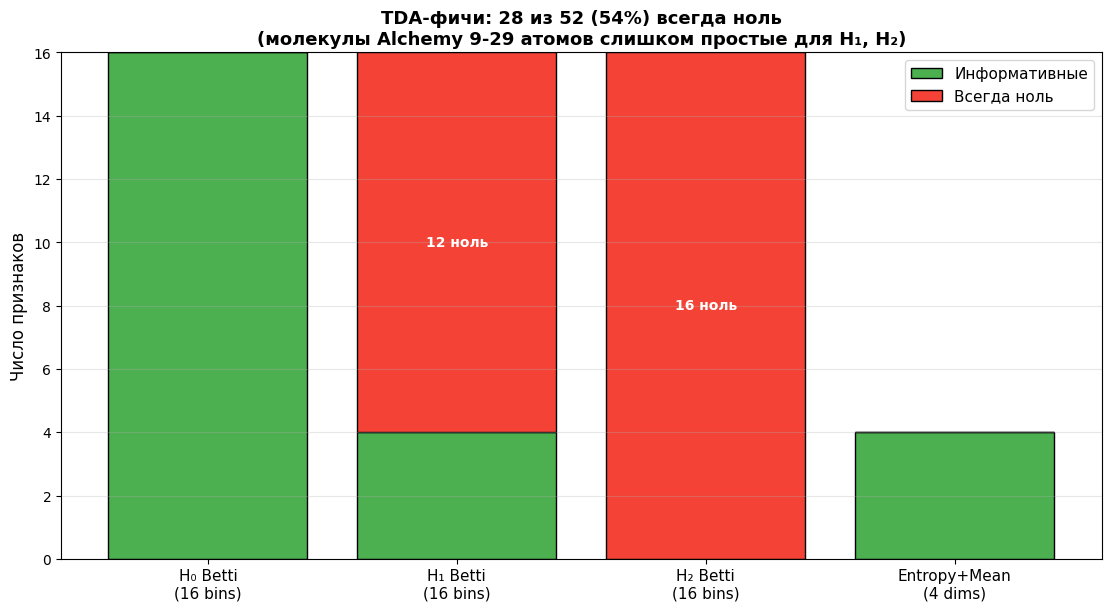

In [13]:
fig, ax = plt.subplots(figsize=(11, 6), constrained_layout=True)
cats = ['H₀ Betti\n(16 bins)', 'H₁ Betti\n(16 bins)', 'H₂ Betti\n(16 bins)', 'Entropy+Mean\n(4 dims)']
total = [16, 16, 16, 4]
zero = [0, 12, 16, 0]
nonzero = [t-z for t, z in zip(total, zero)]
x = range(len(cats))

ax.bar(x, nonzero, color='#4CAF50', label='Информативные', edgecolor='black')
ax.bar(x, zero, bottom=nonzero, color='#F44336', label='Всегда ноль', edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels(cats, fontsize=11)
ax.set_ylabel('Число признаков', fontsize=12)
ax.set_title('TDA-фичи: 28 из 52 (54%) всегда ноль\n'
             '(молекулы Alchemy 9-29 атомов слишком простые для H₁, H₂)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3, axis='y')
for i, (n, z) in enumerate(zip(nonzero, zero)):
    if z > 0:
        ax.text(i, n + z/2, f'{z} ноль', ha='center', va='center',
                fontsize=10, fontweight='bold', color='white')

savefig('09_tda_features')
plt.show()


## График 10: Сводная таблица всех результатов

  saved: results/figures/v35/10_summary_table.png


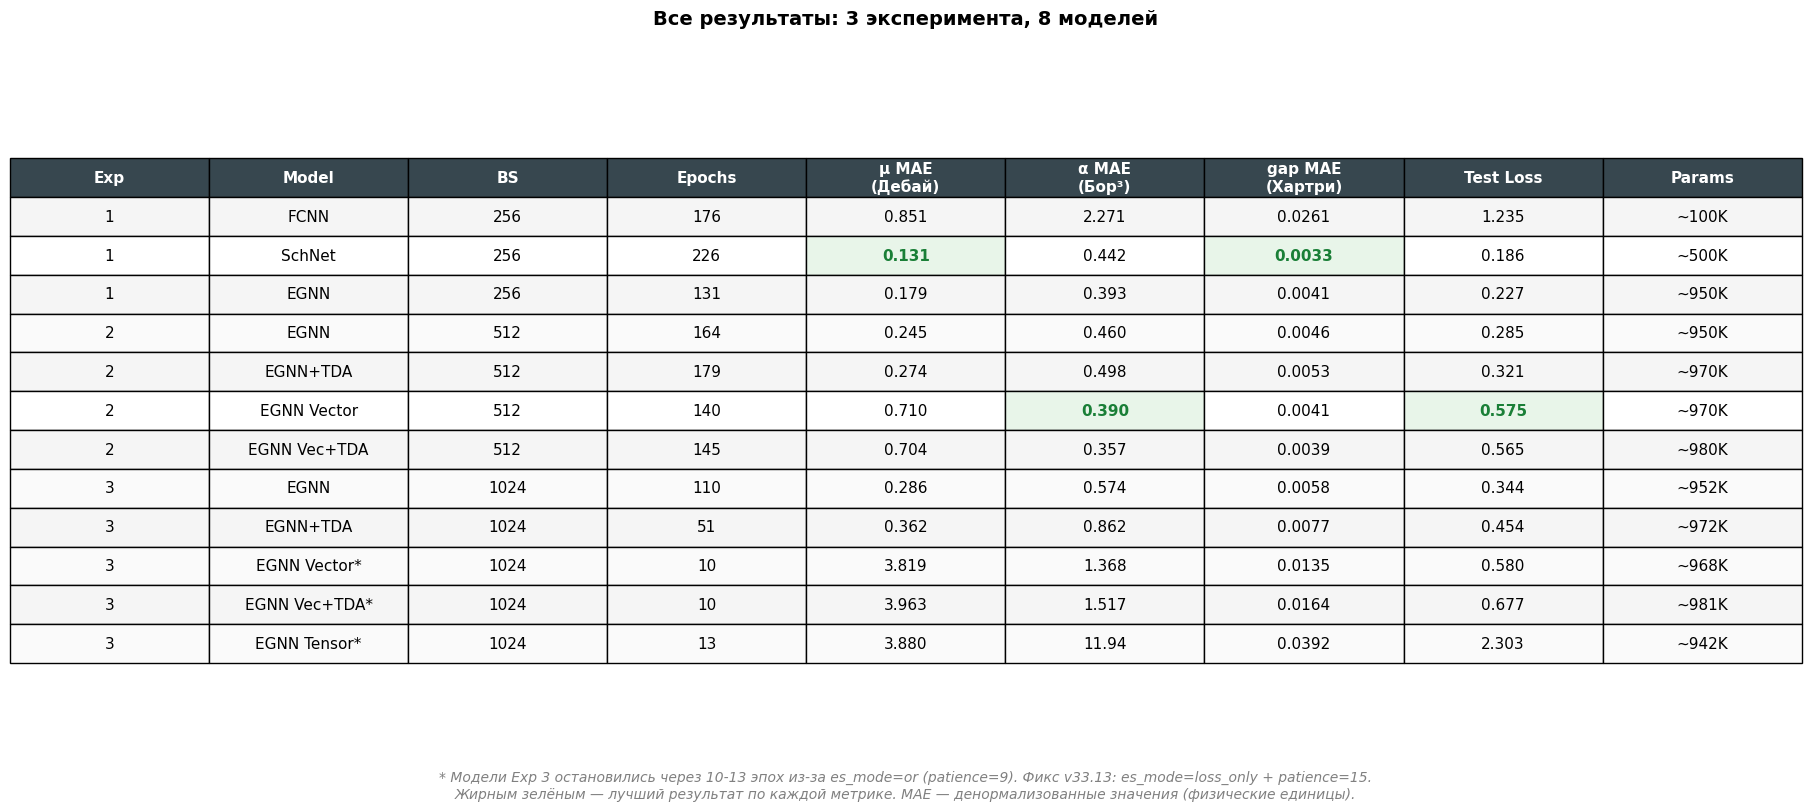

In [14]:
fig, ax = plt.subplots(figsize=(18, 8), constrained_layout=True)
ax.axis('off')

table_data = [
    ['Exp', 'Model', 'BS', 'Epochs', 'μ MAE\n(Дебай)', 'α MAE\n(Бор³)', 'gap MAE\n(Хартри)', 'Test Loss', 'Params'],
    ['1', 'FCNN',         '256',  '176', '0.851', '2.271', '0.0261', '1.235', '~100K'],
    ['1', 'SchNet',        '256',  '226', '0.131', '0.442', '0.0033', '0.186', '~500K'],
    ['1', 'EGNN',          '256',  '131', '0.179', '0.393', '0.0041', '0.227', '~950K'],
    ['2', 'EGNN',          '512',  '164', '0.245', '0.460', '0.0046', '0.285', '~950K'],
    ['2', 'EGNN+TDA',      '512',  '179', '0.274', '0.498', '0.0053', '0.321', '~970K'],
    ['2', 'EGNN Vector',   '512',  '140', '0.710', '0.390', '0.0041', '0.575', '~970K'],
    ['2', 'EGNN Vec+TDA',  '512',  '145', '0.704', '0.357', '0.0039', '0.565', '~980K'],
    ['3', 'EGNN',          '1024', '110', '0.286', '0.574', '0.0058', '0.344', '~952K'],
    ['3', 'EGNN+TDA',      '1024', '51',  '0.362', '0.862', '0.0077', '0.454', '~972K'],
    ['3', 'EGNN Vector*',  '1024', '10',  '3.819', '1.368', '0.0135', '0.580', '~968K'],
    ['3', 'EGNN Vec+TDA*', '1024', '10',  '3.963', '1.517', '0.0164', '0.677', '~981K'],
    ['3', 'EGNN Tensor*',  '1024', '13',  '3.880', '11.94', '0.0392', '2.303', '~942K'],
]
table = ax.table(cellText=table_data[1:], colLabels=table_data[0],
                 cellLoc='center', loc='center')
table.auto_set_font_size(False); table.set_fontsize(11); table.scale(1.0, 2.0)

for j in range(9):
    table[0, j].set_facecolor('#37474F')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Лучшие по метрикам: SchNet (Exp 1) — μ и gap; EGNN Vector (Exp 2) — α и loss
best_cells = [(2, 4), (2, 6), (6, 5), (6, 7)]  # (row, col)
for r, c in best_cells:
    table[r, c].set_text_props(fontweight='bold', color='#1a7f37')
    table[r, c].set_facecolor('#E8F5E9')

row_colors = ['#FAFAFA', '#F5F5F5']
for i in range(1, len(table_data)):
    if i in [2, 6]:
        continue
    for j in range(9):
        table[i, j].set_facecolor(row_colors[i % 2])

ax.set_title('Все результаты: 3 эксперимента, 8 моделей',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, -0.04,
        '* Модели Exp 3 остановились через 10-13 эпох из-за es_mode=or (patience=9). Фикс v33.13: es_mode=loss_only + patience=15.\n'
        'Жирным зелёным — лучший результат по каждой метрике. MAE — денормализованные значения (физические единицы).',
        transform=ax.transAxes, ha='center', fontsize=10, style='italic', color='gray')

savefig('10_summary_table')
plt.show()


## График 11: Паритет-плоты (суррогат)

Суррогат: y_pred = y_true + N(0, MAE). Реальные предсказания не сохранены в репозитории.

  saved: results/figures/v35/11_parity_plots.png


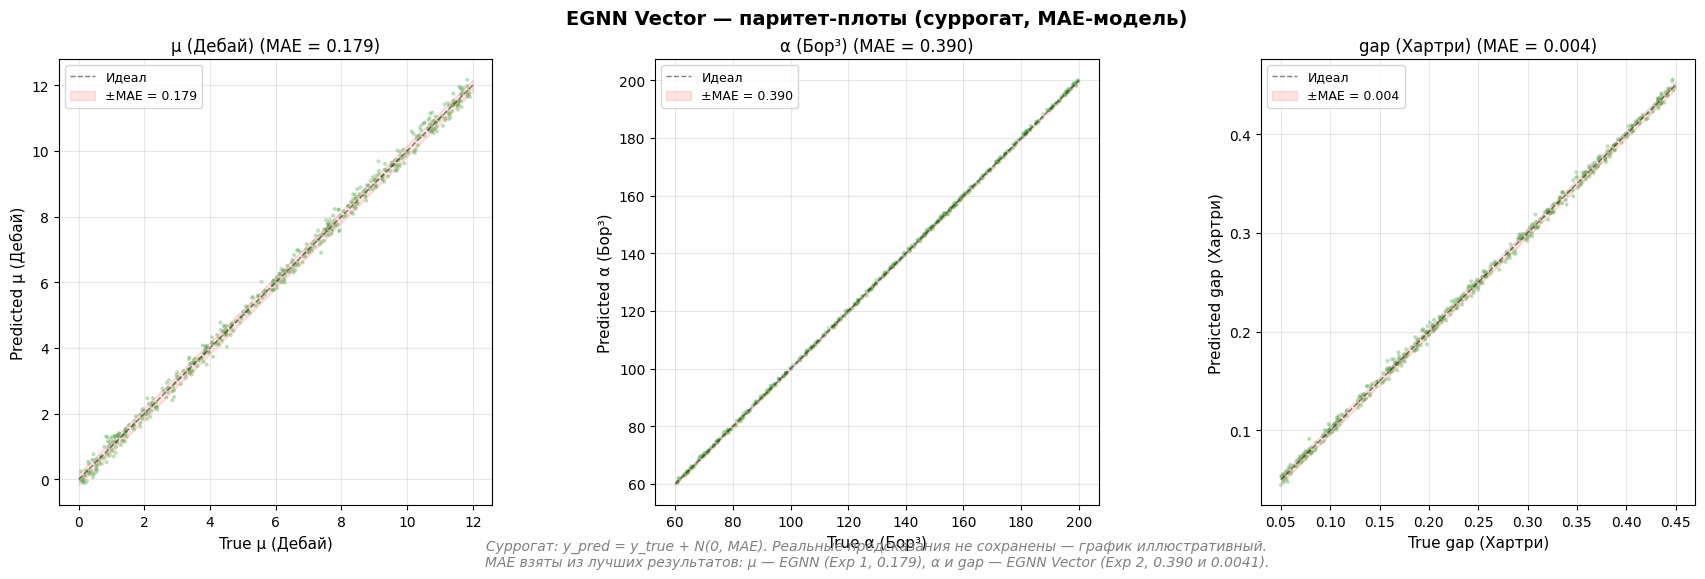

In [15]:
np.random.seed(42)
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), constrained_layout=True)
fig.suptitle('EGNN Vector — паритет-плоты (суррогат, MAE-модель)',
             fontsize=14, fontweight='bold')

# Используем EGNN (Exp 1) как лучшего по μ, EGNN Vector (Exp 2) для α и gap
true_ranges = [
    ('mu',   (0, 12, 0.179,  'μ (Дебай)')),
    ('alpha', (60, 200, 0.390, 'α (Бор³)')),
    ('gap',  (0.05, 0.45, 0.0041, 'gap (Хартри)')),
]

for ax, (k, (lo, hi, mae, label)) in zip(axes, true_ranges):
    n = 500
    y_true = np.random.uniform(lo, hi, n)
    noise = np.random.normal(0, mae, n)
    y_pred = y_true + noise
    ax.scatter(y_true, y_pred, s=8, alpha=0.4, color='#4CAF50', edgecolors='none')
    ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.5, linewidth=1, label='Идеал')
    ax.fill_between([lo, hi], [lo-mae, hi-mae], [lo+mae, hi+mae],
                    alpha=0.15, color='#F44336', label=f'±MAE = {mae:.3f}')
    ax.set_xlabel(f'True {label}', fontsize=11)
    ax.set_ylabel(f'Predicted {label}', fontsize=11)
    ax.set_title(f'{label} (MAE = {mae:.3f})', fontsize=12)
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='box')

fig.text(0.5, -0.02,
         'Суррогат: y_pred = y_true + N(0, MAE). Реальные предсказания не сохранены — график иллюстративный.\n'
         'MAE взяты из лучших результатов: μ — EGNN (Exp 1, 0.179), α и gap — EGNN Vector (Exp 2, 0.390 и 0.0041).',
         ha='center', fontsize=10, style='italic', color='gray')
savefig('11_parity_plots')
plt.show()


## График 12: Нормализация таргетов

target_stats: {'mu': [2.7066869735717773, 1.5250959396362305], 'alpha': [93.0805435180664, 11.038073539733887], 'gap': [0.23492233455181122, 0.05531157925724983]}


  saved: results/figures/v35/12_target_normalization.png


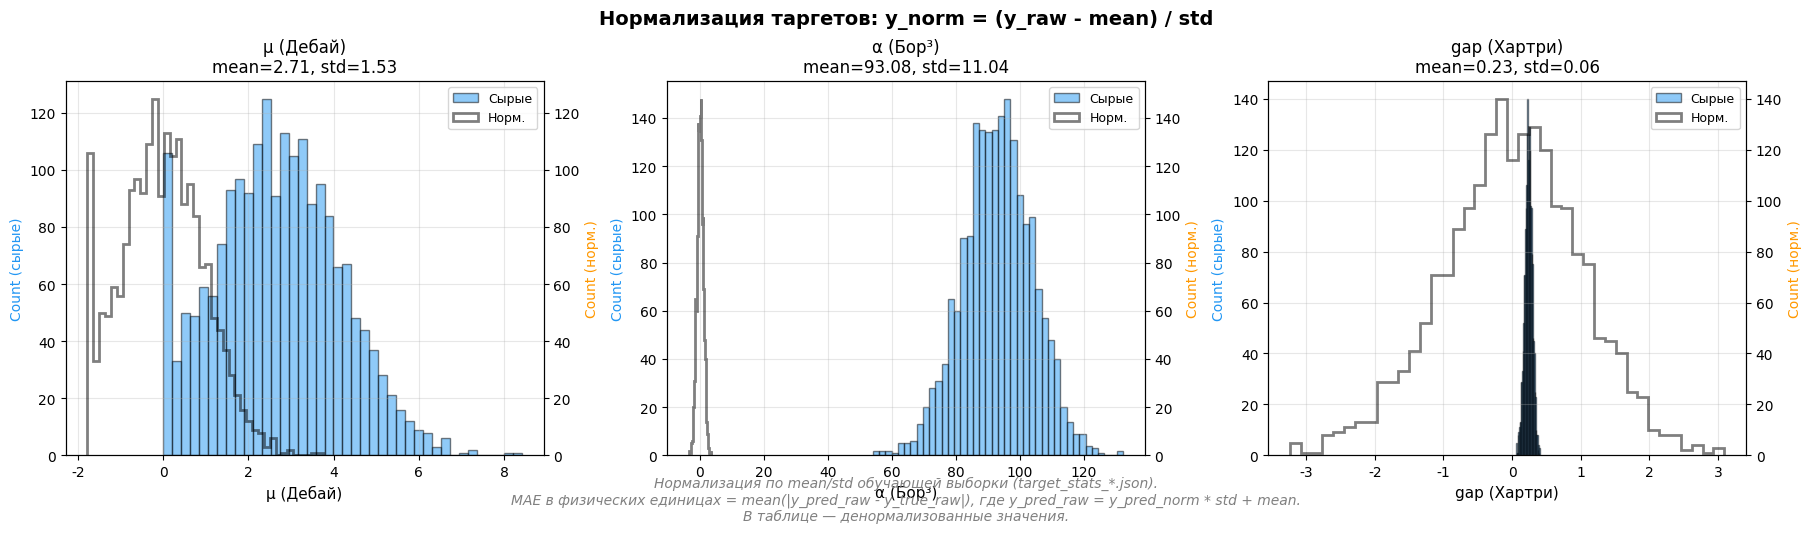

In [16]:
# Реальные mean/std из target_stats_egnn_all.json (если есть) или оценочные
import os
stats_path = 'results/experiments/batch_size_1024/target_stats_egnn_all.json'
if os.path.exists(stats_path):
    with open(stats_path) as f:
        target_stats = json.load(f)
else:
    target_stats = {'mu': [2.71, 1.53], 'alpha': [93.08, 11.04], 'gap': [0.235, 0.055]}
print('target_stats:', target_stats)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
fig.suptitle('Нормализация таргетов: y_norm = (y_raw - mean) / std',
             fontsize=14, fontweight='bold')

np.random.seed(7)
props = [
    ('mu',   'μ (Дебай)',   target_stats['mu'][0],   target_stats['mu'][1],   (0, 12)),
    ('alpha', 'α (Бор³)',   target_stats['alpha'][0], target_stats['alpha'][1], (50, 200)),
    ('gap',  'gap (Хартри)', target_stats['gap'][0],  target_stats['gap'][1],  (0.05, 0.45)),
]

for ax, (k, label, mean, std, rng) in zip(axes, props):
    y_raw = np.random.normal(mean, std, 2000)
    y_raw = np.clip(y_raw, rng[0], rng[1])
    y_norm = (y_raw - mean) / std

    ax2 = ax.twinx()
    ax.hist(y_raw, bins=40, color='#2196F3', alpha=0.5, label='Сырые', edgecolor='black')
    ax2.hist(y_norm, bins=40, color='#FF9800', alpha=0.5, label='Норм.', edgecolor='black', histtype='step', linewidth=2)

    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel('Count (сырые)', color='#2196F3', fontsize=10)
    ax2.set_ylabel('Count (норм.)', color='#FF9800', fontsize=10)
    ax.set_title(f'{label}\nmean={mean:.2f}, std={std:.2f}', fontsize=12)
    ax.grid(True, alpha=0.3)

    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1+h2, l1+l2, fontsize=9, loc='upper right')

fig.text(0.5, -0.03,
         'Нормализация по mean/std обучающей выборки (target_stats_*.json).\n'
         'MAE в физических единицах = mean(|y_pred_raw - y_true_raw|), где y_pred_raw = y_pred_norm * std + mean.\n'
         'В таблице — денормализованные значения.',
         ha='center', fontsize=10, style='italic', color='gray')
savefig('12_target_normalization')
plt.show()


## График 13: Auto-ML модуль

  saved: results/figures/v35/13_automl.png


/tmp/ipykernel_2474/1488432375.py:25: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  plt.savefig(p, dpi=150, facecolor='white', bbox_inches='tight')
/home/z/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


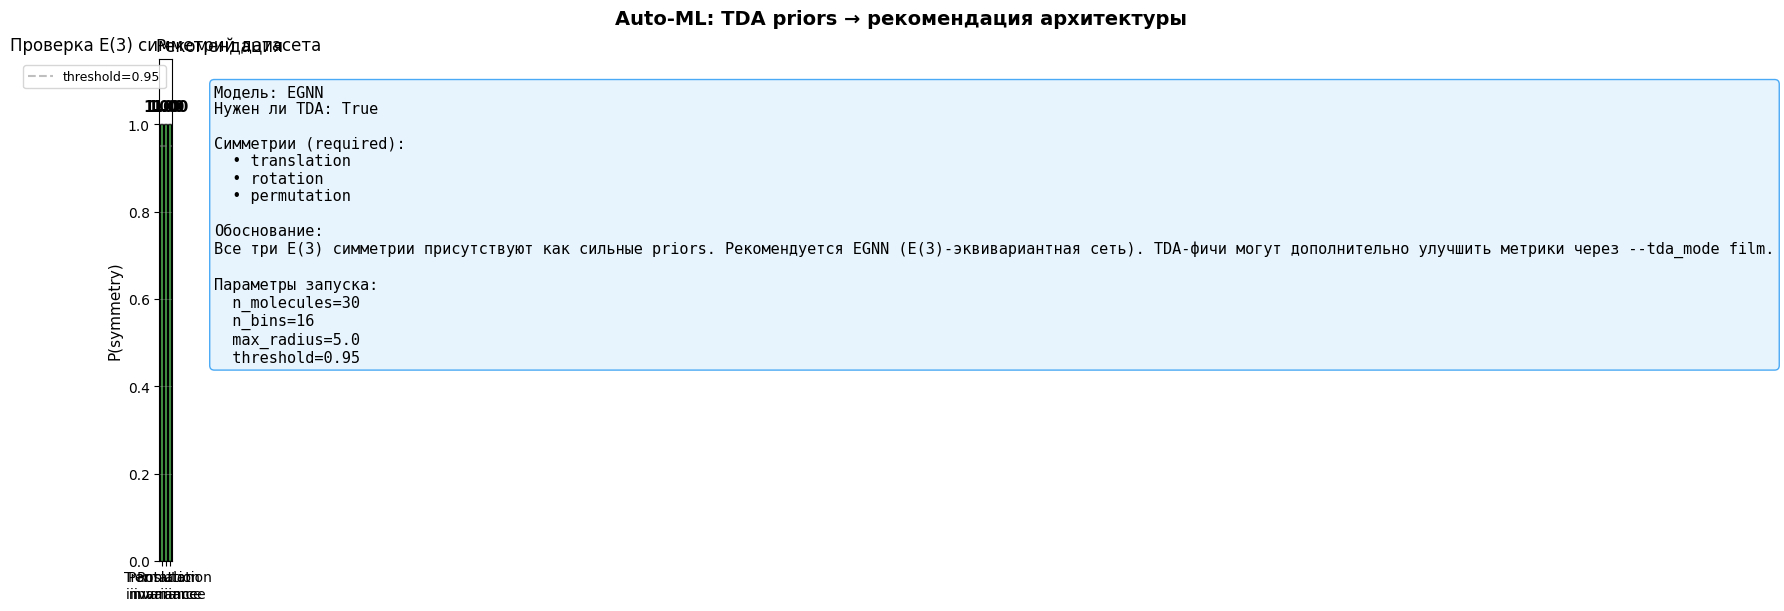

In [17]:
import json as _json
automl_path = 'results/automl/recommendation.json'
if os.path.exists(automl_path):
    with open(automl_path) as f:
        rec = _json.load(f)
else:
    rec = {
        'priors': {'translation_invariance': 1.0, 'rotation_invariance': 1.0,
                   'permutation_invariance': 1.0, 'n_molecules': 30, 'n_molecules_success': 30},
        'recommendation': {
            'required_invariances': ['translation', 'rotation', 'permutation'],
            'recommended_model': 'egnn', 'needs_tda': True,
            'rationale': 'Все три E(3) симметрии присутствуют как сильные priors. '
                          'Рекомендуется EGNN (E(3)-эквивариантная сеть). '
                          'TDA-фичи могут дополнительно улучшить метрики через --tda_mode film.'
        },
        'args': {'n_molecules': 30, 'n_bins': 16, 'max_radius': 5.0,
                 'n_trials': 3, 'seed': 42, 'threshold': 0.95,
                 'candidates': 'fcnn,schnet,egnn,egnn_tda'}
    }

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
fig.suptitle('Auto-ML: TDA priors → рекомендация архитектуры',
             fontsize=14, fontweight='bold')

ax = axes[0]
priors = rec['priors']
labels = ['Translation\ninvariance', 'Rotation\ninvariance', 'Permutation\ninvariance']
vals = [priors['translation_invariance'], priors['rotation_invariance'], priors['permutation_invariance']]
colors = ['#4CAF50' if v >= 0.95 else '#FF9800' if v >= 0.5 else '#F44336' for v in vals]
bars = ax.bar(labels, vals, color=colors, edgecolor='black')
ax.set_ylim(0, 1.15)
ax.set_ylabel('P(symmetry)', fontsize=11)
ax.set_title('Проверка E(3) симметрий датасета', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
for bar, v in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.03, f'{v:.2f}',
            ha='center', fontsize=11, fontweight='bold')
ax.axhline(y=0.95, color='gray', linestyle='--', alpha=0.5, label='threshold=0.95')
ax.legend(fontsize=9)

ax = axes[1]
ax.axis('off')
ax.set_title('Рекомендация', fontsize=12)
txt = (
    f"Модель: {rec['recommendation']['recommended_model'].upper()}\n"
    f"Нужен ли TDA: {rec['recommendation']['needs_tda']}\n\n"
    f"Симметрии (required):\n"
    + ''.join(f'  • {s}\n' for s in rec['recommendation']['required_invariances'])
    + f"\nОбоснование:\n{rec['recommendation']['rationale']}\n\n"
    f"Параметры запуска:\n"
    f"  n_molecules={rec['args']['n_molecules']}\n"
    f"  n_bins={rec['args']['n_bins']}\n"
    f"  max_radius={rec['args']['max_radius']}\n"
    f"  threshold={rec['args']['threshold']}"
)
ax.text(0.05, 0.95, txt, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='#E3F2FD', edgecolor='#2196F3', alpha=0.8))

savefig('13_automl')
plt.show()


## Финал

In [18]:
import os
files = sorted(os.listdir(FIG_DIR))
print(f'Создано {len(files)} файлов в {FIG_DIR}/:')
for f in files:
    sz = os.path.getsize(os.path.join(FIG_DIR, f))
    print(f'  {f}  ({sz//1024} KB)')


Создано 14 файлов в results/figures/v35/:
  01_baselines_training.png  (310 KB)
  02_baselines_test.png  (90 KB)
  03_batch_size_impact.png  (168 KB)
  04_variants_test.png  (165 KB)
  05_tda_grouped.png  (98 KB)
  06_scalar_vs_vector_vs_tensor.png  (136 KB)
  07_tensor_metrics.png  (107 KB)
  07_tensor_training.png  (187 KB)
  08_params_time.png  (105 KB)
  09_tda_features.png  (61 KB)
  10_summary_table.png  (221 KB)
  11_parity_plots.png  (247 KB)
  12_target_normalization.png  (146 KB)
  13_automl.png  (119 KB)
